In [ ]:
# NOTE - only run this cell if you are using google colab. Otherwise, skip to the next cell
# If the cell fails to compile on the first attempt, just restart the session and run it again.

import sys

# This notebook requires Python 3.11 due to pinned dependencies in cpu_requirements.txt
v = sys.version_info
if (v.major, v.minor) != (3, 11):
    raise RuntimeError(
        f"This notebook requires Python 3.11, but the current runtime is "
        f"Python {v.major}.{v.minor}.\n\n"
        f"To fix this in Colab:\n"
        f"  1. Go to Runtime → Change runtime type\n"
        f"  2. Under 'Version' select 2025.07\n"
        f"  3. Click Save and re-run this cell\n\n"
        f"If 3.11 is not available in the dropdown, your Colab account may not "
        f"have access to the fallback runtime."
    )

# Clone the repo
import os
if not os.path.exists('2026_tyagi_boodry_IDP_design'):
    !git clone https://github.com/shrinivaslab/2026_tyagi_boodry_IDP_design.git
%cd 2026_tyagi_boodry_IDP_design

# Install dependencies
%pip install -r cpu_requirements.txt

# If you want to use the GPU, uncomment the following line and run the cell
# %pip install -r gpu_requirements.txt

### Predictor Class Overview ###

Class definition. Must provide:
- `model_name`: can be 'dimer', 'finches' or 'rpa'. Defines which physics method to perform the threoretical calculation.
- `ff_type`: can be 'mpipi', 'mpipi_gg', 'calvados1', 'calvados2', 'hps_dignon', 'hps_tesei', 'hps_fb', 'hps_urry', or 'kh-d'. Defines interactions between all pairs of amino acids (as an input to the physics model)
- `pH_mode`: can be 'normal' or 'pH'. Defines how charges on the amino acids are calculated. `pH_mode = 'normal'` uses the charges defined by the corresponding force field while `pH_mode = 'pH'` uses the Henderson-Hasselbalch equation for residue charge calculation.
- condition specification: must provide details on how many conditions to run the prediction at. Includes `temps`, `salts`, and `pHs`. All three must be lists with at least 1 element (more elements define additional combinations of conditions). Note that `pHs` will not do anything to the calculation unless `pH_mode = 'pH'`. Temperatures are defined in K, salt concentrations in mM.
    - For example, to run all calculations at the 'base' conditions used in the paper, one would set `temps = [300]`, `salts = [150]`, `pHs = [7.4]`. This will run the interaction parameter calculations at temperature = 300 K, salt concentration = 150 mM, and pH = 7.4.
    - If you instead what to calculate at low and high salt concentrations, you would set `temps = [300]`, `salts = [150, 450]`, and `pHs = [7.4]`. This will run all calculations at two points: 1. temp = 300 K, salt concentration = 150 mM, pH = 7.4 _and_ 2. temp = 300 K, salt concentration = 450 mM, pH = 7.4.

Some key functionalities: <br>
1. Predictor.predict_pair - takes two sequences as an argument (both strings). Returns interaction parameters at all conditions specified when the Predictor object was created.

In [ ]:
# predict_pair usage example
import models.predictor
from models.predictor import Predictor


temps = [300]
salts = [150, 450]
pHs = [7.4]

predictor = Predictor(model_name = 'dimer', ff_type = 'calvados2', pH_mode = 'normal', temps = temps, salts = salts, pHs = pHs)

seq1 = 'K'*50
# returned values are at all conditions specified when the Predictor object was created
vals = predictor.predict_pair(seq1, seq1)

# to get the chi value:
b = 0.38*3.6 # for calvados2/mpipi models. For HPS use 3.0

# only need (0.5 - ...) for self interactions
chi_val = 0.5 - (vals / (b**3 * len(seq1)**2))

all_conditions = predictor.all_conditions
for i, condition in enumerate(all_conditions):
    print(f"Condition {i+1}: {condition}")
    print(f'interaction parameter: {vals[i]}')
    print(f'chi value: {chi_val[i]}')

Condition 1: (300, 150, 7.4)
interaction parameter: 13196.673828125
chi value: -1.5618932247161865
Condition 2: (300, 450, 7.4)
interaction parameter: 4432.4140625
chi value: -0.19253545999526978


2. Predictor.predict_batch - takes two lists of sequences as an argument, computes interaction parameters between list1[i] and list2[i] (the two lists must be the same length). If list2 is not provided, defaults to computing self-interactions on all sequences in list1. Also takes print_check (bool) which just prints the sequence pair and then all conditions + interaction parameters at those conditions for each sequence pair. Returns a nested list where out[i] refers to sequence pair list1[i], list2[i] and entry out[i][j] refers to the interaction parameter at all_conditions[j] for that sequence.

In [ ]:
import jax.numpy as jnp
import jax

import models.predictor
from models.predictor import Predictor
from models.ff_models import RES_ALPHA
import time
import numpy as onp
import matplotlib.pyplot as plt
from tqdm import tqdm
from models.ff_models import seq_to_one_hot

n_seqs = 100
# do self-virial prediction on 100 random sequences
seqs1 = [''.join(onp.random.choice(list(RES_ALPHA), size = 50)) for _ in range(n_seqs)]

# define conditions in lists with 1+ elements

# no phosphorylation/methylation here - reason being you can just substitute 'S' with 'Z' in the sequence to imitate serine phosphorylation
# same with 'T'/'B' for threonine phosphorylation and 'R'/'X' for arginine methylation
temps = [300, 360]
salts = [150]
pHs = [7.4]

# can have model types: 'dimer', 'finches', 'rpa'
# can have ff types: 'calvados1', 'calvados2', 'mpipi_gg', 'mpipi', 'kh-d', 'hps_tesei', 'hps_dignon', 'hps_urry', 'hps_fb'

# FINCHES will operate much slower than dimer or RPA models 

# this just initializes the predictor object - running happens below
# however, must define the conditions that you care about
predictor = Predictor(model_name = 'dimer', ff_type = 'calvados2', pH_mode = 'normal', temps = temps, salts = salts, pHs = pHs)

import time
start_time = time.time()
results = predictor.predict_batch(seqs1 = seqs1, seqs2 = seqs1, print_check = True)
end_time = time.time()
print(f"Time taken: {end_time - start_time} seconds")

# for dimer model, to go from virial to chi, use the following formula:

# chi = 0.5 - virial / (b**3 * len(seq)**2)


# where b is the hard-sphere diameter (0.38 * 3.6 nm) for calvados2
# only for dimer model though, all other interaction parameters are absolute


Batch predictions:
-------------------------
Sequence Pair 0: GACGVPRTEQPLRIFYKNLIESYVASLXZHHSBEACHMQFLAGDITQFRW vs GACGVPRTEQPLRIFYKNLIESYVASLXZHHSBEACHMQFLAGDITQFRW
-------------------------
Temperature: 300 K, Salt concentration: 150 mM, pH: 7.4 -> -353.6990966796875
-------------------------
Temperature: 360 K, Salt concentration: 150 mM, pH: 7.4 -> -104.4925537109375
-------------------------
Sequence Pair 1: MKAKIKRFEYRBKABWMYCZKMKDKFCBZHNDKTTIQSZGTCNYXHMBIN vs MKAKIKRFEYRBKABWMYCZKMKDKFCBZHNDKTTIQSZGTCNYXHMBIN
-------------------------
Temperature: 300 K, Salt concentration: 150 mM, pH: 7.4 -> -389.7134094238281
-------------------------
Temperature: 360 K, Salt concentration: 150 mM, pH: 7.4 -> -97.68231201171875
-------------------------
Sequence Pair 2: KLAXHCLNRPBAAZRYWYVADFKABVQDHXIKKEZHWGAHCCYCLNAQZB vs KLAXHCLNRPBAAZRYWYVADFKABVQDHXIKKEZHWGAHCCYCLNAQZB
-------------------------
Temperature: 300 K, Salt concentration: 150 mM, pH: 7.4 -> -213.25328063964844
----------------

### Designer class overview ###

Some commonalities between all types of design:<br>
1. Must provide Designer object with model_name, ff_type, and pH_mode (same definitions as above) when defining a new Designer object
2. All types of single-sequence design run through a wrapper function called designer.design_sequence(...) that baseline has the following requirements: must provide sequence_length, design_type, num_iterations, metapredict_constraint (a boolean as to whether you want to apply metapredict or not) and then a specification of conditions (temps/salts/pHs/phosphorylation/methylation)
3. Condition specification: passed in the same format as the predictor class definition. There are restrictions depending on what type of design you're doing with how many unique condition 'points' you can pass (e.g. value design is done at exactly one condition)
    - for phosphorylation and methylation, conditions are passed as lists denoting '0' for no phosphorylation/methylation, and '1' for phosphorylation/methylation. Note if either is passed as '1', you must also include either phos_locs or meth_locs which are lists that define which locations in the sequence are phosphorylated/methylated.
4. Each of the design_type arguments requires other arguments passed to designer.design_sequence(...) depending on what you're trying to do.

Now going individually: (all additional arguments are still passed to the same design_sequence function, just have to identify them. See examples below)
1. design_type == 'value' <br>
The 'exact_chi' optimization from Figure 1C-D (for different models). You specify a target interaction parameter value and the optimization generates a sequence that gets as close as it can to that value. Requires additional arguments:<br>
    - 'target_value': number that specifies the targeted interaction parameter value you're trying to get close to. Scaling is different for different models, see Figure 1C for scaling behavior of dimer and FINCHES models.

In [ ]:
# design for specific interaction parameter value

import jax
import models.designer
from models.designer import Designer


temps = [300]
salts = [150]
pHs = [7.4]
phosphorylation = [0]
methylation = [0]
designer = Designer(model_name = 'dimer', ff_type = 'calvados2', pH_mode = 'normal')

# target value provided for dimer model in units of chi
targeted_value = 0.25

import time
start_time = time.time()
argmax_seq, aux = designer.design_sequence(
    sequence_length = 100, 
    design_type = 'value', 
    num_iterations = 500, 
    temps = temps, 
    salts = salts, 
    pHs = pHs,
    phosphorylation = phosphorylation,
    methylation = methylation,
    target_value = targeted_value,
    metapredict_constraint = True,
    )
end_time = time.time()
print(f"Time taken: {end_time - start_time} seconds")

final_chi = aux[1][-1]

print('-'*100)
print(f"Final chi value: {final_chi}")
print(f"Final sequence: {argmax_seq}")
print('-'*100)


Compiling and running 500 iterations...
Optimization complete!
Final sequence: VAAAEVAADDEVVVDDVAEVQAVVEEVEAAADDPATADVDHAADAVPDAEEAVEVAVEVEEGHDHNAASEVAAVDSQPNPSVNTQVVTHTETTEESVAAE
Final loss: 0.00017986077000387013
Time taken: 10.788513898849487 seconds
----------------------------------------------------------------------------------------------------
Final chi value: [0.24981779]
Final sequence: VAAAEVAADDEVVVDDVAEVQAVVEEVEAAADDPATADVDHAADAVPDAEEAVEVAVEVEEGHDHNAASEVAAVDSQPNPSVNTQVVTHTETTEESVAAE
----------------------------------------------------------------------------------------------------


2. design_type == '1d_switch' <br>
The switch-type optimization in Figure 2a. Enforces that number of conditions to run at is exactly 2 and raises an error otherwise. Requires additional arguments:
    - 'threshold': Number that specifies how far away from neutral interaction the designed sequence should be at the two conditions. Appropriate values are model-dependent. If not specified, this is set to 1/sqrt(seq_length) which is generally appropriate for the dimer model.
    - 'response_type': Can be 'contractor' or 'expander'. Defines whether predicted interaction goes from favorable -> unfavorable or vice-versa.

In [ ]:
# salt sensor optimization
import jax
import models.designer
from models.designer import Designer

temps = [300]
salts = [150, 450]
pHs = [7]
phosphorylation = [0]
methylation = [0]

designer = Designer(model_name = 'dimer', ff_type = 'calvados2', pH_mode = 'normal')

response_types = ['contractor', 'expander']
seq_len = 50
threshold = 1/jnp.sqrt(seq_len)

all_seqs = []
all_final_vals = []
all_losses = []
labels = []
for response_type in response_types:
    argmax_seq, aux = designer.design_sequence(
        sequence_length = seq_len,
        design_type = '1d_switch',
        num_iterations = 500,
        temps = temps,
        salts = salts,
        pHs = pHs,
        phosphorylation = phosphorylation,
        methylation = methylation,
        metapredict_constraint = True,
        threshold = threshold,
        response_type = response_type,
    )

    labels.append(response_type)
    all_seqs.append(argmax_seq)
    all_final_vals.append(aux[1][-1])
    all_losses.append(aux[0][-1])


Compiling and running 500 iterations...
Optimization complete!
Final sequence: YRWRWWWRRWWRRRRWRRFRRRWRYRWYWRRRWRFWFRWWWRRRRYRRWY
Final loss: 0.0
Compiling and running 500 iterations...
Optimization complete!
Final sequence: EEEEEEKKKKKKKKKKKKKEEEEEEKKKKEEEEEEEEEEEKKKKEEEEEE
Final loss: 0.03480517864227295


3. design_type == 'designed_response' <br>
Figure 2b. Requires additional arguments:
    - 'response_type': Same as 1d_switch optimization. Can be 'contractor' or 'expander'.
    - 'response_profile': Can be 'early_step', 'late_step', 'linear', or 'bandpass'. What you want the shape of the response curve to look like.
        - early_step: tries to maximize change in interaction parameter value over the first half of the condition axis.
        - late-step: opposite of early step, tries to maximize change in interaction parameter value over the latter half of the condition axis
        - linear: tries to maintain constant change in interaction parameter value going across condition axis.
        - bandpass: tries to have similar interaction parameter value at the extremes of the condition axis with different behavior inbetween. Note that 'response_type' for the bandpass option defines which direction it moves in first (e.g. response_type = 'contractor' means a bandpass sensor will first contact, then expand back to the original state).
    - 'num_subdividions': Optional integer that specifies how many points to sample at inbetween extremes along the condition axis. Default is 7.

Compiling and running 500 iterations...
Optimization complete!
Final sequence: MFKSKLSVTGSGHKRRSIMGSGRRCSGYYRSRLRRSRHKKSKYFIFIGTS
Final loss: 0.08165609836578369
Compiling and running 500 iterations...
Optimization complete!
Final sequence: MKAPQPVQRKSRHGKKRPPQSKKPRSKRRESDVPDSARKDSASPKRPGVG
Final loss: 0.1308191865682602


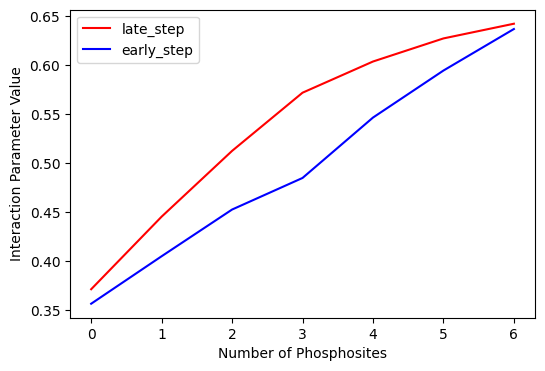

In [ ]:
# designed response optimziation
import jax
import models.designer
from models.designer import Designer
import jax.numpy as jnp

temps = [300]
salts = [150]
pHs = [7.4]
phosphorylation = [0, 1]
methylation = [0]

phos_locs = [10, 20, 25, 30, 35, 40]


designer = Designer(model_name = 'dimer', ff_type = 'calvados2', pH_mode = 'normal')

response_profiles = ['late_step', 'early_step']
all_final_vals = []

for response_profile in response_profiles:
    argmax_seq, aux = designer.design_sequence(
        sequence_length = 50,
        design_type = 'designed_response',
        num_iterations = 500,
        response_type = 'contractor',
        response_profile = response_profile,
        temps = temps,
        salts = salts,
        pHs = pHs,
        phosphorylation = phosphorylation,
        methylation = methylation,
        metapredict_constraint = True,
        phos_locs = phos_locs,
    )

    final_vals = aux[1][-1]
    all_final_vals.append(final_vals)


import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize = (6, 4))
ax.plot(all_final_vals[0], label = 'late_step', color = 'red')
ax.plot(all_final_vals[1], label = 'early_step', color = 'blue')
ax.set_xlabel('Number of Phosphosites')
ax.set_ylabel('Interaction Parameter Value')
ax.legend()
plt.show()



4. design_type == 'multi_dimensional_switch' <br>
Figure 2d, works generally for any number of specified conditions. Requires additional arguments:
    - 'threshold': Same as 1d_switch optimization. Distance (in interaction parameter units) above/below 'neutral' interaction. Again default value is 1/sqrt(seq_len) which is for the dimer model.
    - 'targets': (Not super intuitive right now) a list of 0s and 1s that specifies at which conditions you want the sequence to be expanded/contracted. Targets has a '1' in the index of all_conditions where the sequence should be expanded and vice-versa for '0'. E.g. for the simple 1d case if I have all_conditions = [(300, 150, 7.4, 0, 0), (300, 450, 7.4, 0, 0)] and define targets as [0, 1] I want a salt expander (favorable interactions at low salt / all_conditions[0], disfavorable interactions at high salt / all_conditions[1]). If any ideas on how to make this more intuitive let me know!

In [ ]:
# 2 dimensional switch optimization
import jax
import models.designer
from models.designer import Designer
import jax.numpy as jnp

temps = [300]
salts = [150, 450]
pHs = [7.4]
phosphorylation = [0, 1]
methylation = [0]

phos_locs = [10, 20, 25, 30, 40]


designer = Designer(model_name = 'dimer', ff_type = 'calvados2', pH_mode = 'normal')

targets = [1, 0, 0, 0] # kind of an OR gate

argmax_seq, aux = designer.design_sequence(
    sequence_length = 50,
    design_type = 'multi_dimensional_switch',
    num_iterations = 500,
    temps = temps,
    salts = salts,
    pHs = pHs,
    phosphorylation = phosphorylation,
    methylation = methylation,
    metapredict_constraint = True,
    targets = targets,
    phos_locs = phos_locs,
)


print(argmax_seq)

Compiling and running 500 iterations...
Optimization complete!
Final sequence: WWYRRYWRWRSRRWRRRWYRSWWWRSWYWRSRYRRRRWRYSRRRRWYRYY
Final loss: 0.0
WWYRRYWRWRSRRWRRRWYRSWWWRSWYWRSRYRRRRWRYSRRRRWYRYY


5. design_type == 'reference'<br>
Analogous to the experimental section with the FUS LCD - optimize based on cross-virial/chi with a reference sequence. Requires additional arguments:
    - 'target_value': A number representing now the cross-interaction between the sequence being optimized and the reference sequence.
    - 'reference_sequence': A string of the protein sequence whose cross-interaction is calculated relative to the optimzied sequence.

In [ ]:
# client/excluder optimization
import jax
import models.designer
from models.designer import Designer


temps = [300]
salts = [150]
pHs = [7.4]
phosphorylation = [0]
methylation = [0]

designer = Designer(model_name = 'dimer', ff_type = 'calvados2', pH_mode = 'normal')

# reference sequence is the same from Figure 4 in the paper - FUS LC domain
ref_seq = 'ASNDYTQQATQSYGAYPTQPGQGYSQQSSQPYGQQSYSGYSQSTDTSGYGQSSYSSYGQSQNTGYGTQSTPQGYGSTGGYGSSQSSQSSYGQQSSYPGYGQQPAPSSTSGSYGSSSQSSSYGQPQSGSYSQQPSYGGQQQSYGQQQSYNPPQGYGQQNQYNS'

sequence_length = 50
opt_type = 'client'

argmax_seq, aux = designer.design_sequence(
    sequence_length = sequence_length,
    design_type = 'reference',
    num_iterations = 500,
    temps = temps,
    salts = salts,
    pHs = pHs,
    phosphorylation = phosphorylation,
    methylation = methylation,
    opt_type = opt_type,
    reference_sequence = ref_seq,
    metapredict_constraint = True
)

Compiling and running 500 iterations...
Optimization complete!
Final sequence: MMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMM
Final loss: nan


6. design_type == 'two_sequence'<br>
Related to Figure 3. Optimize two sequences simultaneously, taking into account each one's self-interaction and their cross interaction. Requires additional arguments: <br>
    - 'behavior': Can be 'condensed_mix' or 'condensed_demix'. Specifies desired phenotype of the two sequences. 
        - 'condensed_mix': Each sequence should have sufficiently favorable self-interaction to condense. The cross-interaction between the two sequences should be favorable as well to produce a single dense phase with both sequences.
        - 'condensed_demix': Each sequence should have sufficiently favorable self-interaction to condense. The cross-interaction between the two sequences should be disfavorable to produce two unique dense phases, one for each sequence. 
        - Have to add more options here

In [8]:
# multiple sequence optimization
import jax
import models.designer
from models.designer import Designer


temps = [300]
salts = [150]
pHs = [7.4]
phosphorylation = [0]
methylation = [0]

designer = Designer(model_name = 'dimer', ff_type = 'calvados2', pH_mode = 'normal')

seq1, seq2, aux = designer.design_sequence(
    sequence_length = 50,
    design_type = 'two_sequence',
    num_iterations = 500,
    temps = temps,
    salts = salts,
    pHs = pHs,
    phosphorylation = phosphorylation,
    methylation = methylation,
    behavior = 'condensed_demix'
)

print(seq1)
print(seq2)

Compiling and running 500 iterations...
Optimization complete!
Final sequence: WYYYYWYYWYIFWWYYYYWYFWYYHYYWWYYHHWQHHWHWYYWWYYIIYNEDDDDDDYDFCYWRYRRRRFRRRRRRRRRRRRRFDRRRFYDDDDDDDDDD
Final loss: 0.013728350400924683
WYYYYWYYWYIFWWYYYYWYFWYYHYYWWYYHHWQHHWHWYYWWYYIIYN
EDDDDDDYDFCYWRYRRRRFRRRRRRRRRRRRRFDRRRFYDDDDDDDDDD


6. design_type == 'batch' <br>
Related to Figure 1D and uniquely uses a separate function (designer.design_batch(...)). The same logic as design_type == 'value', but paralellized to enable simultaneous optimization of many sequences at once. Requires additional arguments:
    - 'num_sequences': How many sequences to optimize.
    - 'target_values': Value(s) to optimize each sequence to. Can be a float or a list of floats. If a single float, all designed sequences are optimized to go to that interaction parameter value. If passed as a list, the length of the list must be equal to num_sequences (len(target_values) == num_sequences). In this case, the sequence returned in seqs[i] is optimized to have the interaction parameter in target_values[i]

In [9]:
# batch sequence design
import jax
import models.designer
from models.designer import Designer
from models.predictor import Predictor
designer = Designer(model_name='dimer', ff_type='calvados2', pH_mode='normal')

seqs, results = designer.design_batch(
    sequence_length=50,
    num_sequences=32,
    num_iterations=500,
    temps=[300], salts=[150], pHs=[7.4],
    phosphorylation=[0], methylation=[0],
    target_values=0.5,
)

Compiling batch of 32 sequences x 500 iterations...
Optimization complete!
  Seq 0: chi=0.500235  loss=0.000253  STAGPAPNVHGRGTDNVTAAAICVVTVPTGATMMTTGTMPPATPAMPVHT
  Seq 1: chi=0.499949  loss=0.000111  TMQATPAAVVPSAPHTPMNPSGPGNGPQHMVAQHVNNAPQVTPMQVAAHP
  Seq 2: chi=0.500554  loss=0.000557  GMPAMPAAANPTSDHATAASVVQVGSTSGSSQAPPCSQAMAQHPGGTTIP
  Seq 3: chi=0.498723  loss=0.001266  SQPPGATAQQQQQQADPSVTNASTAPSANVTSHHNTHQQQTVMQVPAPQF
  Seq 4: chi=0.499787  loss=0.000232  IQLIPVPTACSMSHAAPTGSQDAADSPGNQAATAQPGCAIQSQGPHGSAA
  Seq 5: chi=0.500040  loss=0.000106  MTATQPTSAHTATATAGCSAAEPQPNNGCITSVMAPANQPTGNNPQTKGA
  Seq 6: chi=0.499971  loss=0.000103  AGPQVCGHHSDTTAHSVTHNASQTARTAPNHHTAASAHQGAATAQHATAA
  Seq 7: chi=0.499975  loss=0.000102  WVVQASMHEQAATPPTSQQQPTRTQSTSASPANVSNTACHAVVPAQHQQQ
  Seq 8: chi=0.500033  loss=0.000104  DVVPMVTPANGPQPVTQHVTCVANVHGLSPTHMNGPAAQQNPSGQAAPSP
  Seq 9: chi=0.499935  loss=0.000118  PVIGPAQGTTTPPQCAMAPAQHPSAGTVNSSAPVSVHITTSTQANTHAAV
  ... and 22 more sequences
